(chap_aihc_model_development)=
# From Clinical Question to Credible Model: A Development Workflow
**Content creators:** [Abhishek](https://github.com/moturuab)


Clinical machine-learning projects rarely fail because nobody tried a sufficiently complicated algorithm. More often, the intended use was vague, the prediction time was not fixed, information leaked across splits, a threshold was chosen after examining the test set, or performance was summarized with one attractive number. This tutorial builds a small but complete workflow around those failure points.

## At a glance

| Item | What this tutorial uses |
|---|---|
| Clinical question | At an inpatient index time, estimate the probability of deterioration within 24 hours |
| Teaching data | A deliberately simulated multi-site cohort with temporal and site shifts |
| Model ladder | Prevalence-only baseline → regularized logistic regression → random forest → gradient boosting |
| Selection | Candidate comparison and threshold selection on validation data only |
| Final checks | Locked temporal and external-site tests, calibration, subgroup estimates, and monitoring plan |
| Runtime | About 30–35 minutes on a CPU; no GPU is required |
| Main output | A traceable model-development record, not a clinically deployable model |

### Learning objectives

By the end, you should be able to:

1. translate a broad clinical idea into a precise intended-use statement;
2. define the unit of analysis, index time, outcome window, and exclusions before modelling;
3. create train, validation, temporal-test, and external-site partitions that answer different questions;
4. compare weak and stronger models without assuming that complexity must win;
5. assess discrimination, calibration, precision–recall behaviour, and operational consequences; and
6. describe what evidence would still be needed before clinical use.

:::{admonition} 30–35-minute core route
:class: tip
Work through Sections 1–10 in order: define the use case, inspect the controlled shifts, fit the four-model ladder, select on validation data, and then open the locked tests. If time remains, Sections 11–13 add subgroup review, documentation, and monitoring; finish with the synthesis in Section 14. Long implementation cells are collapsed on the website but remain fully commented and runnable.
:::

:::{admonition} Scope and safety
:class: warning
Every patient, encounter, value, site, and outcome in the main example is fictional. The notebook demonstrates development mechanics under controlled shifts. Its numerical results do **not** estimate clinical performance, validate a deterioration score, or support patient-care decisions.
:::


## 1. Development is a lifecycle, not a single training step

The model itself occupies only one part of the work. Decisions made before training determine whether the resulting number is meaningful; decisions after training determine whether performance can be maintained safely.

This ordering is substantive. For example, “predict deterioration” is incomplete until we know *for whom*, *at what time*, using *which information*, over *what horizon*, and *what action* the estimate is meant to inform. Similarly, a retrospective test result does not demonstrate that an alert can be integrated into a real workflow without delay, overload, inequity, or automation bias.


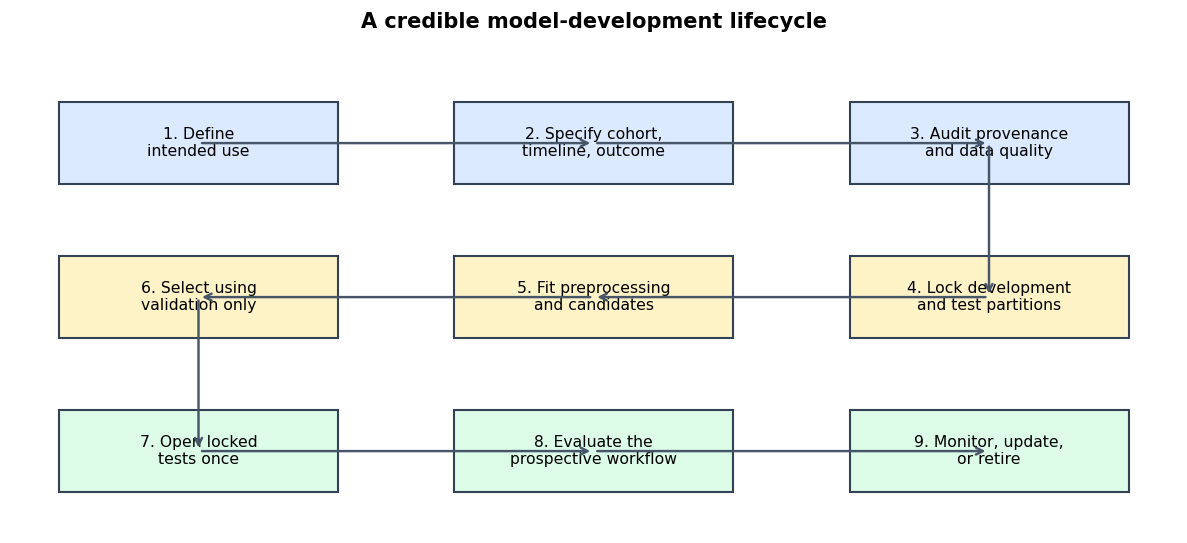

In [1]:
# Draw the lifecycle with Matplotlib so the notebook and exported site need no
# diagram extension. The snake layout keeps nine stages readable in one figure.
import matplotlib.pyplot as plt

stages = [
    "Define\nintended use",
    "Specify cohort,\ntimeline, outcome",
    "Audit provenance\nand data quality",
    "Lock development\nand test partitions",
    "Fit preprocessing\nand candidates",
    "Select using\nvalidation only",
    "Open locked\ntests once",
    "Evaluate the\nprospective workflow",
    "Monitor, update,\nor retire",
]
positions = [
    (0.04, 0.72), (0.38, 0.72), (0.72, 0.72),
    (0.72, 0.40), (0.38, 0.40), (0.04, 0.40),
    (0.04, 0.08), (0.38, 0.08), (0.72, 0.08),
]

fig, ax = plt.subplots(figsize=(12, 5.0))
ax.axis("off")
box_width, box_height = 0.24, 0.17

# Each stage is a distinct decision record, not merely a software operation.
for stage_number, ((x, y), label) in enumerate(zip(positions, stages), start=1):
    colour = "#dbeafe" if stage_number <= 3 else "#fef3c7" if stage_number <= 6 else "#dcfce7"
    ax.add_patch(plt.Rectangle(
        (x, y), box_width, box_height,
        facecolor=colour, edgecolor="#334155", linewidth=1.2,
    ))
    ax.text(
        x + box_width / 2, y + box_height / 2, f"{stage_number}. {label}",
        ha="center", va="center", fontsize=9,
    )

# Connect box centres in lifecycle order; arrows also show the two row turns.
centres = [(x + box_width / 2, y + box_height / 2) for x, y in positions]
for start, end in zip(centres[:-1], centres[1:]):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops={"arrowstyle": "->", "color": "#475569", "lw": 1.4},
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("A credible model-development lifecycle", pad=12, weight="bold")
plt.show()


## 2. Make the intended use testable

We will develop a **decision-support** model for adult inpatients. At an index time four hours after admission, the model estimates whether a composite deterioration outcome will occur in the next 24 hours. The estimate could support review by a trained care team; it is not an autonomous diagnosis or treatment recommendation.

| Design element | Teaching specification | Why it matters |
|---|---|---|
| Population | Adult inpatient encounters meeting data-availability criteria | Defines who may receive a score |
| Unit of analysis | One index encounter per fictional patient | Prevents multiple rows from being mistaken for independent people |
| Index time | Four hours after admission | Separates information available now from future information |
| Predictors | Demographics, comorbidity, initial vital signs, and initial laboratory values | Creates an auditable feature boundary |
| Outcome | Fictional composite deterioration within the next 24 hours | Defines the label and prediction horizon |
| User/action | Trained team may prioritize a chart review | Connects predictions to a workflow without automating care |
| Important exclusions | Under 18, outcome already present, or required source feed unavailable | Avoids scoring patients outside the intended setting |

The corresponding non-goals are just as important: this model will not identify a diagnosis, replace bedside assessment, determine treatment, or be assumed transportable to a new hospital. Those claims would require different data and evidence.


## 3. Why use a simulated cohort here?

Real longitudinal health records are sensitive, locally structured, and difficult to distribute in an executable teaching resource. Simulation also lets us deliberately create three phenomena that students need to see: a nonlinear signal, a change over calendar time, and a site whose documentation and case mix differ. We know the data-generating process because we wrote it, so we can isolate methodological mistakes without exposing patient information.

That convenience comes at a major cost. Simulated data omit the irregular measurement, coding ambiguity, treatment effects, selection mechanisms, label errors, and social context of real care. Even when the simulated model behaves realistically, the dataset is still an authored example—not a miniature clinical trial.

:::{admonition} How to interpret every result below
:class: danger
Treat the numerical values as a **worked demonstration of the workflow**. They are intentionally kept away from near-perfect performance because real clinical outcomes contain irreducible uncertainty and unmeasured determinants. However, moderate-looking performance is not evidence of realism, usefulness, fairness, safety, or generalizability. A model trained on these data must never be used for care.
:::


In [2]:
# Reproducible setup ---------------------------------------------------------
# A single seed controls the simulated cohort, candidate models, and bootstrap.
# Reproducibility is useful for teaching, but a real project should also repeat
# training across seeds to quantify optimization and sampling variability.
SEED = 2026

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)


## 4. Construct a cohort with plausible uncertainty and deliberate shifts

The next cell is longer because it keeps the data-generating assumptions visible. Notice three design choices.

First, the outcome is probabilistic rather than a deterministic rule. Two otherwise similar patients can have different outcomes because important determinants are unmeasured. Second, the signal combines approximately linear effects with a few nonlinear interactions. Logistic regression should therefore improve substantially on prevalence alone, while a nonlinear model may recover some additional structure. Third, Site D and later years differ slightly. This creates a credible reason for temporal and external validation to be worse than internal validation.

The coefficients below are not clinical effect estimates. They are only parameters of the fictional generator.


In [3]:
def simulate_encounters(n, site, year, seed):
    '''Create one fictional index encounter per patient.

    Parameters
    ----------
    n : int
        Number of independent fictional patients to generate.
    site : str
        Site label. Site D is intentionally shifted for external testing.
    year : int
        Calendar year. Later years receive a small temporal shift.
    seed : int
        Local seed so that each site-year block is reproducible.

    Returns
    -------
    pandas.DataFrame
        Predictors, metadata, and one binary 24-hour outcome per patient.
    '''
    local_rng = np.random.default_rng(seed)

    # Site D has a somewhat older, more comorbid case mix. These differences
    # are large enough to inspect but not so large that the site is caricatured.
    external = 1 if site == "D" else 0
    age = np.clip(local_rng.normal(63 + 4 * external, 16, n), 18, 95)
    sex = local_rng.choice(["female", "male"], n, p=[0.52, 0.48])
    comorbidity = np.clip(local_rng.poisson(2.0 + 0.5 * external, n), 0, 8)

    # A latent severity variable induces realistic correlation among measured
    # values. It is deliberately not saved as a feature: clinicians never have
    # direct access to the generator's hidden state.
    severity = local_rng.normal(0, 1, n)
    heart_rate = 82 + 10 * severity + local_rng.normal(0, 13, n)
    systolic_bp = 124 - 8 * severity + local_rng.normal(0, 16, n)
    oxygen_sat = 96 - 1.5 * severity + local_rng.normal(0, 1.8, n)
    creatinine = np.exp(0.0 + 0.22 * severity + 0.012 * (age - 60) + local_rng.normal(0, 0.35, n))
    lactate = np.exp(-0.05 + 0.27 * severity + local_rng.normal(0, 0.38, n))

    # Admission service is categorical and partly associated with case mix.
    service_prob = np.array([0.43, 0.32, 0.25]) if not external else np.array([0.51, 0.27, 0.22])
    service = local_rng.choice(["medicine", "surgery", "cardiology"], n, p=service_prob)

    # Outcome mechanism: mostly smooth main effects plus clinically plausible
    # nonlinearities. The final noise term represents unmeasured determinants
    # and prevents the task from becoming unrealistically easy.
    linear_risk = (
        -3.00
        + 0.018 * (age - 60)
        + 0.16 * comorbidity
        + 0.015 * (heart_rate - 80)
        - 0.026 * (systolic_bp - 120)
        - 0.17 * (oxygen_sat - 95)
        + 0.34 * np.log1p(creatinine)
        + 0.42 * np.log1p(lactate)
        + 0.18 * (service == "medicine")
    )

    # These terms reward flexible models, but only modestly: low blood pressure
    # matters more when heart rate is high, and risk rises at both age extremes.
    nonlinear_risk = (
        # A smooth U-shape makes both bradycardia-like and tachycardia-like
        # extremes informative. Additive logistic regression cannot represent
        # both directions with one heart-rate coefficient.
        0.75 * np.clip(((heart_rate - 82) / 18) ** 2, 0, 2)
        # The remaining thresholds create limited interactions and tail effects
        # that a tree ensemble can learn without making the label deterministic.
        + 0.85 * ((systolic_bp < 105) & (heart_rate > 98))
        + 0.65 * (lactate > 1.6)
        + 0.65 * ((age < 40) | (age > 80))
    )

    # Later years have a small baseline change; Site D also has a measurement
    # relationship not fully learned from Sites A-C. This is controlled shift,
    # not a claim about how any real institution behaves.
    shift = 0.10 * (year - 2022) + 0.16 * external - 0.12 * external * (oxygen_sat - 95)
    unmeasured = local_rng.normal(0, 0.92, n)
    probability = 1 / (1 + np.exp(-(linear_risk + nonlinear_risk + shift + unmeasured)))
    outcome = local_rng.binomial(1, probability)

    frame = pd.DataFrame({
        "patient_id": [f"{site}-{year}-{i:05d}" for i in range(n)],
        "site": site,
        "year": year,
        "age": age.round(1),
        "sex": sex,
        "service": service,
        "comorbidity_count": comorbidity,
        "heart_rate": heart_rate.round(1),
        "systolic_bp": systolic_bp.round(1),
        "oxygen_saturation": oxygen_sat.round(1),
        "creatinine": creatinine.round(2),
        "lactate": lactate.round(2),
        "deterioration_24h": outcome,
    })

    # Missingness depends on workflow context. We do not use the outcome to
    # create it, because the outcome occurs after the prediction time.
    # Site D has more missing lactate, representing a documentation difference.
    lactate_missing_p = 0.10 + 0.08 * external + 0.05 * (service == "surgery")
    creatinine_missing_p = 0.05 + 0.04 * (year >= 2024)
    frame.loc[local_rng.random(n) < lactate_missing_p, "lactate"] = np.nan
    frame.loc[local_rng.random(n) < creatinine_missing_p, "creatinine"] = np.nan
    return frame


# Build separate site-year blocks so the future and external tests are explicit.
blocks = []
for site_index, site in enumerate(["A", "B", "C", "D"]):
    for year in [2021, 2022, 2023, 2024]:
        # Sites A-C supply development data; Site D is reserved as an external site.
        n_block = 700 if site != "D" else 500
        blocks.append(simulate_encounters(n_block, site, year, SEED + 100 * site_index + year))

cohort = pd.concat(blocks, ignore_index=True)
cohort.sample(5, random_state=SEED)


,patient_id,site,year,age,sex,service,comorbidity_count,heart_rate,systolic_bp,oxygen_saturation,creatinine,lactate,deterioration_24h
6854,C-2022-00554,C,2022,73.8,female,surgery,2,85.2,116.3,97.9,1.14,NaN,0
8379,C-2024-00679,C,2024,54.3,female,cardiology,2,120.1,145.8,96.4,0.32,0.43,1
4511,B-2023-00311,B,2023,81.9,male,medicine,3,97.8,95.5,98.1,0.87,NaN,1
5423,B-2024-00523,B,2024,60.0,female,surgery,2,81.4,112.4,96.5,1.30,1.25,0
2231,A-2024-00131,A,2024,64.9,male,cardiology,0,110.7,108.0,96.3,2.13,NaN,1


**Reading the output.** Each row is one fictional patient at one prediction time. The row contains only variables intended to be available at that time. There are no post-outcome treatments, discharge fields, or future measurements. That boundary is more important than whether a column is technically easy to extract.

The random sample is a basic inspection, not a quality assessment. Next we examine whether the partitions actually differ in size, outcome prevalence, missingness, and case mix.


## 5. Lock partitions before comparing models

The four partitions answer four different questions:

- **Training (Sites A–C, 2021–2022):** estimate parameters and fit preprocessing.
- **Validation (Sites A–C, 2023):** compare candidate configurations and select a threshold.
- **Temporal test (Sites A–C, 2024):** estimate performance on a later period after all choices are locked.
- **External-site test (Site D, 2023–2024):** probe transportability to a site with different case mix and documentation.

The tests are not extra validation sets. If we use their results to change features, hyperparameters, or thresholds and then report the same results, they are no longer untouched tests.


In [4]:
# Boolean masks make the split rules inspectable and easy to audit.
split_masks = {
    "train": cohort["site"].isin(["A", "B", "C"]) & cohort["year"].isin([2021, 2022]),
    "validation": cohort["site"].isin(["A", "B", "C"]) & (cohort["year"] == 2023),
    "temporal_test": cohort["site"].isin(["A", "B", "C"]) & (cohort["year"] == 2024),
    "external_test": (cohort["site"] == "D") & cohort["year"].isin([2023, 2024]),
}

# Assert that each encounter belongs to at most one analysis partition. A test
# like this catches overlapping date or site rules before any model is fitted.
membership_count = sum(mask.astype(int) for mask in split_masks.values())
assert membership_count.max() == 1, "At least one row appears in multiple partitions."

partition_rows = []
for split_name, mask in split_masks.items():
    part = cohort.loc[mask]
    partition_rows.append({
        "partition": split_name,
        "rows": len(part),
        "outcome_prevalence": part["deterioration_24h"].mean(),
        "mean_age": part["age"].mean(),
        "missing_lactate": part["lactate"].isna().mean(),
    })

partition_summary = pd.DataFrame(partition_rows).set_index("partition")
partition_summary


,rows,outcome_prevalence,mean_age,missing_lactate
partition,,,,
train,4200,0.248,62.936,0.114
validation,2100,0.256,62.882,0.109
temporal_test,2100,0.286,62.861,0.115
external_test,1000,0.358,67.707,0.215


**Interpretation.** The partitions differ before any model is fitted. Outcome prevalence rises from 0.248 in training and 0.256 in validation to 0.286 in the temporal test and 0.358 at the external site. The external cohort is also older on average (67.7 versus about 62.9 years) and has nearly twice as much missing lactate (21.5% versus 11.4% in training). Those differences change the AUPRC reference, probability calibration, and likely workload even if model code runs without errors.

In a real study, this table would be expanded to include eligibility counts, data-source versions, label completeness, clinically important subgroups, measurement units, and reasons for missingness. Unexpected differences should be investigated with clinical, operational, and data-engineering partners—not automatically normalized away.


## 6. Keep preprocessing inside the model pipeline

Median imputation, standardization, and one-hot encoding all learn from data. Fitting them before the split would let validation and test distributions influence the representation. A `Pipeline` makes the training boundary explicit: every candidate learns preprocessing from training rows only, and the fitted transformations are reused unchanged elsewhere.

The model ladder has a purpose:

| Candidate | What it can learn | Why include it |
|---|---|---|
| Prevalence baseline | One constant probability | Establishes the minimum honest comparator |
| Logistic regression | Additive linear effects after preprocessing | Strong, interpretable baseline; often difficult to beat meaningfully |
| Random forest | Piecewise nonlinearities and interactions | Tests whether flexible rules help, but can be unstable or poorly calibrated |
| Gradient boosting | Sequential shallow-tree corrections | Can recover nonlinearities and interactions; still requires careful validation |

“Stronger” here means **more flexible**, not automatically more clinically useful. A small numerical gain may not justify a model that is harder to explain, calibrate, reproduce, or maintain.


In [5]:
# Identifiers, site, and year describe provenance and splitting; they are not
# model inputs. Excluding them prevents the estimator from learning shortcuts
# tied to the artificial IDs or the reserved validation design.
target = "deterioration_24h"
numeric_features = [
    "age", "comorbidity_count", "heart_rate", "systolic_bp",
    "oxygen_saturation", "creatinine", "lactate",
]
categorical_features = ["sex", "service"]
model_features = numeric_features + categorical_features

X = cohort[model_features]
y = cohort[target]

def rows_for(split_name):
    '''Return feature and outcome rows for one already-locked partition.'''
    mask = split_masks[split_name]
    return X.loc[mask].copy(), y.loc[mask].copy()

X_train, y_train = rows_for("train")
X_val, y_val = rows_for("validation")

# Numeric values are imputed and standardized. Missing-indicator columns allow
# the linear model to represent that a measurement was absent, while preserving
# the original value/missingness distinction in one auditable transformation.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

# handle_unknown='ignore' prevents a new category at inference from crashing
# the pipeline. Production systems should still log and review unseen values.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

candidates = {
    "Prevalence baseline": Pipeline([
        ("preprocess", copy.deepcopy(preprocessor)),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "Logistic regression": Pipeline([
        ("preprocess", copy.deepcopy(preprocessor)),
        ("model", LogisticRegression(C=0.7, max_iter=2000, random_state=SEED)),
    ]),
    "Random forest": Pipeline([
        ("preprocess", copy.deepcopy(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=18, max_features=0.75,
            random_state=SEED, n_jobs=-1,
        )),
    ]),
    "Gradient boosting": Pipeline([
        ("preprocess", copy.deepcopy(preprocessor)),
        ("model", GradientBoostingClassifier(
            n_estimators=180, learning_rate=0.035, max_depth=2,
            min_samples_leaf=28, subsample=0.85, random_state=SEED,
        )),
    ]),
}

print(f"Training rows: {X_train.shape}; validation rows: {X_val.shape}")


Training rows: (4200, 9); validation rows: (2100, 9)


## 7. Define the evaluation contract before seeing results

No single metric answers every question.

- **AUROC** asks how often an event receives a higher score than a non-event across possible thresholds. It can look respectable even when positive predictive value is low.
- **Average precision (AUPRC)** emphasizes the positive class and must be interpreted relative to prevalence. Its no-skill reference is approximately the event prevalence.
- **Brier score** is the mean squared probability error; lower is better. It combines calibration and discrimination.
- **Log loss** penalizes confident errors strongly; lower is better.

We will select the candidate with the lowest validation Brier score among models that show useful discrimination. That rule reflects this tutorial's emphasis on risk estimates rather than ranks alone. A different use case could justify a different prespecified rule.


In [6]:
def probability_metrics(y_true, probability):
    '''Calculate complementary probability-model metrics.

    The clipping only protects log loss from numerical log(0); it does not alter
    the probabilities used for the other metrics.
    '''
    # Preserve the model's actual probabilities for discrimination and Brier
    # score. Only log loss needs clipping to avoid numerical log(0).
    raw_probability = np.asarray(probability)
    clipped_probability = np.clip(raw_probability, 1e-6, 1 - 1e-6)
    # Keep all metrics in one helper so every candidate is evaluated using the
    # same discrimination and probability-quality contract.
    return {
        "AUROC": roc_auc_score(y_true, raw_probability),
        "AUPRC": average_precision_score(y_true, raw_probability),
        "Brier (lower)": brier_score_loss(y_true, raw_probability),
        "Log loss (lower)": log_loss(y_true, clipped_probability),
    }


fitted_candidates = {}
validation_rows = []
validation_probabilities = {}

for name, estimator in candidates.items():
    # clone() guarantees that each candidate begins unfitted and cannot inherit
    # state from another model. Only the training partition enters fit().
    fitted = clone(estimator).fit(X_train, y_train)
    probability = fitted.predict_proba(X_val)[:, 1]

    fitted_candidates[name] = fitted
    validation_probabilities[name] = probability
    validation_rows.append({"model": name, **probability_metrics(y_val, probability)})

validation_results = pd.DataFrame(validation_rows).set_index("model")
validation_results.sort_values("Brier (lower)")


,AUROC,AUPRC,Brier (lower),Log loss (lower)
model,,,,
Gradient boosting,0.773,0.605,0.148,0.464
Random forest,0.765,0.582,0.152,0.472
Logistic regression,0.747,0.567,0.157,0.488
Prevalence baseline,0.500,0.256,0.191,0.569


**How to read this table.** The observed ladder is gradual rather than spectacular. The prevalence baseline has AUROC 0.500, AUPRC 0.256, and Brier score 0.191. Logistic regression improves these to 0.747, 0.567, and 0.157. Random forest reaches 0.765/0.582/0.152, and gradient boosting reaches 0.773/0.605/0.148. The nonlinear candidates recover some authored interactions, but the gain over the linear model is modest and all results remain far from perfection.

Do not treat a ranking to three decimal places as certain. Candidate results share the same finite validation set, and training randomness can matter. More importantly, the best statistical score might still lose on interpretability, latency, calibration, subgroup behaviour, integration cost, or prospective usefulness. Complexity earns consideration only when its incremental value is reproducible and decision-relevant.


In [7]:
# Apply the prespecified validation rule. The test sets remain unopened.
eligible = validation_results[validation_results["AUROC"] >= 0.60]
selected_name = eligible["Brier (lower)"].idxmin()
selected_model = fitted_candidates[selected_name]
selected_val_probability = validation_probabilities[selected_name]

print(f"Selected on validation data: {selected_name}")


Selected on validation data: Gradient boosting


## 8. Inspect calibration instead of relying on one summary score

Calibration asks whether predicted probabilities agree with observed frequencies. If patients receiving scores near 0.30 deteriorate only 10% of the time, the model's probabilities are not directly interpretable as risks—even if its ranking is useful.

Calibration plots are estimates, not ground truth. Bin choices can hide or exaggerate problems, and sparse high-risk bins are noisy. We therefore show each bin's sample count as well as the calibration curve.


,predicted_risk,observed_rate,patients
0,0.077,0.072,263
1,0.104,0.084,262
2,0.128,0.144,263
3,0.156,0.176,262
4,0.194,0.202,262
5,0.259,0.251,263
6,0.381,0.393,262
7,0.647,0.726,263


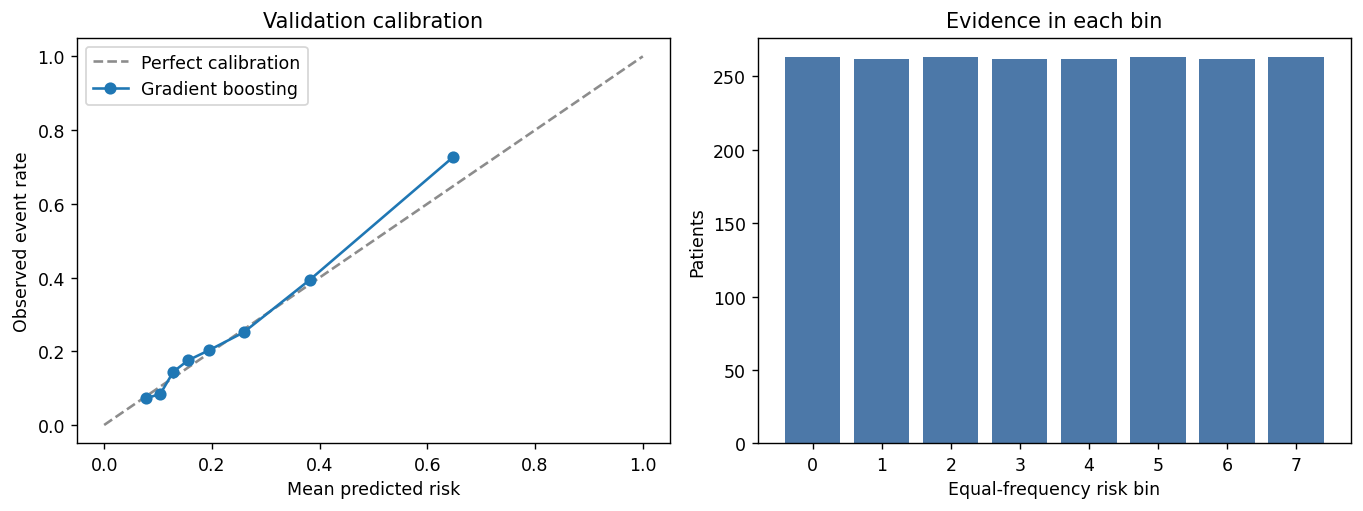

In [8]:
def calibration_table(y_true, probability, n_bins=8):
    '''Create equal-frequency bins with observed and predicted risks.'''
    # Phase 1: pair outcomes and probabilities without modifying row order.
    table = pd.DataFrame({"outcome": np.asarray(y_true), "probability": probability})
    # duplicates='drop' handles the constant prevalence baseline gracefully.
    table["bin"] = pd.qcut(table["probability"], q=n_bins, duplicates="drop")
    # Phase 2: expose each bin's denominator alongside its calibration estimate.
    return table.groupby("bin", observed=True).agg(
        predicted_risk=("probability", "mean"),
        observed_rate=("outcome", "mean"),
        patients=("outcome", "size"),
    ).reset_index(drop=True)


calibration = calibration_table(y_val, selected_val_probability)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot([0, 1], [0, 1], "--", color="0.55", label="Perfect calibration")
axes[0].plot(calibration["predicted_risk"], calibration["observed_rate"], "o-", label=selected_name)
axes[0].set(xlabel="Mean predicted risk", ylabel="Observed event rate", title="Validation calibration")
axes[0].legend()

axes[1].bar(range(len(calibration)), calibration["patients"], color="#4C78A8")
axes[1].set(xlabel="Equal-frequency risk bin", ylabel="Patients", title="Evidence in each bin")
plt.tight_layout()
plt.show()

calibration


**Interpretation.** Seven of the eight equal-frequency bins are close to the diagonal in this validation set. The highest-risk bin contains 263 patients, with mean predicted risk 0.647 and observed event rate 0.726; the difference is therefore visible but not based on only a handful of cases. This remains an internal, simulated calibration estimate. A real analysis should estimate calibration-in-the-large and calibration slope with uncertainty, then consider recalibration only under a prespecified change-control process.


## 9. Select an operating point using the validation workflow

A probability model does not become an alerting system until a threshold and response are specified. Instead of maximizing a generic statistic, suppose the review team can assess approximately 12% of scored encounters. We choose the validation threshold that flags that proportion.

This does **not** establish that reviewing 12% is beneficial or feasible. It translates a capacity assumption into expected alert volume, sensitivity, and positive predictive value so that the operational trade-off is visible.


In [9]:
# Phase 1: translate the fictional team's stated capacity into a threshold.
review_fraction = 0.12

# The threshold is determined from validation predictions only. Using a test
# quantile would adapt the deployed workflow after seeing the evaluation set.
locked_threshold = float(np.quantile(selected_val_probability, 1 - review_fraction))

def threshold_metrics(y_true, probability, threshold):
    '''Summarize the consequences of one locked decision threshold.'''
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "flagged_fraction": prediction.mean(),
        "sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "positive_predictive_value": tp / (tp + fp) if tp + fp else np.nan,
        "alerts_per_100": 100 * prediction.mean(),
        "missed_events_per_100": 100 * fn / len(y_true),
    }

pd.Series(threshold_metrics(y_val, selected_val_probability, locked_threshold), name="validation")


threshold                     0.481
flagged_fraction              0.120
sensitivity                   0.344
specificity                   0.957
positive_predictive_value     0.734
alerts_per_100               12.000
missed_events_per_100        16.810
Name: validation, dtype: float64

**Interpretation.** The validation-derived threshold is 0.481 and flags exactly 12.0% of validation encounters. At that operating point, sensitivity is only 0.344, specificity is 0.957, PPV is 0.734, and 16.8 events are missed per 100 scored encounters. The high PPV therefore does not mean the workflow captures most events; it reflects a deliberately narrow review capacity.

Sensitivity and positive predictive value move in opposite directions as capacity changes. Neither is “the” correct objective without specifying the harms of a missed event, the harms and workload of a false alert, the effectiveness of the response, and who bears those consequences.

The threshold is now part of the locked configuration. Quietly changing it at another site creates a new model–workflow combination that requires evaluation, versioning, and governance.


## 10. Open the locked tests once

Only now do we evaluate the chosen model and threshold on the later period and external site. The temporal test asks whether performance persists after calendar change. The external test asks whether the complete pipeline transports to a different site. A decline is not an inconvenience to optimize away; it is evidence about where the current claim stops.


In [10]:
test_rows = []
test_probabilities = {}

for split_name in ["temporal_test", "external_test"]:
    X_test, y_test = rows_for(split_name)
    # Every candidate was already fitted and locked before either test was
    # opened. Reporting the full ladder reveals whether a small validation gain
    # persists; these test numbers must not be used for another selection round.
    for model_name, fitted_model in fitted_candidates.items():
        probability = fitted_model.predict_proba(X_test)[:, 1]
        result_row = {
            "partition": split_name,
            "model": model_name,
            **probability_metrics(y_test, probability),
        }
        if model_name == selected_name:
            test_probabilities[split_name] = probability
            # Operational columns apply only to the selected model because the
            # 12% validation-derived threshold belongs to that configuration.
            result_row.update({
                key: value
                for key, value in threshold_metrics(y_test, probability, locked_threshold).items()
                if key != "threshold"
            })
        test_rows.append(result_row)

locked_test_results = pd.DataFrame(test_rows).set_index(["partition", "model"])
locked_test_results


AUROC  AUPRC  Brier (lower)  \
partition     model                                              
temporal_test Prevalence baseline  0.500  0.286          0.206   
              Logistic regression  0.739  0.552          0.173   
              Random forest        0.753  0.584          0.168   
              Gradient boosting    0.757  0.592          0.167   
external_test Prevalence baseline  0.500  0.358          0.242   
              Logistic regression  0.763  0.663          0.188   
              Random forest        0.755  0.661          0.190   
              Gradient boosting    0.769  0.677          0.187   

                                   Log loss (lower)  flagged_fraction  \
partition     model                                                     
temporal_test Prevalence baseline             0.602               NaN   
              Logistic regression             0.523               NaN   
              Random forest                   0.512               NaN   
              Gradient boosting               0.508             0.128   
external_test Prevalence baseline             0.682               NaN   
              Logistic regression             0.558               NaN   
              Random forest                   0.570               NaN   
              Gradient boosting               0.556             0.152   

                                   sensitivity  specificity  \
partition     model                                           
temporal_test Prevalence baseline          NaN          NaN   
              Logistic regression          NaN          NaN   
              Random forest                NaN          NaN   
              Gradient boosting          0.308        0.945   
external_test Prevalence baseline          NaN          NaN   
              Logistic regression          NaN          NaN   
              Random forest                NaN          NaN   
              Gradient boosting          0.324        0.944   

                                   positive_predictive_value  alerts_per_100  \
partition     model                                                            
temporal_test Prevalence baseline                        NaN             NaN   
              Logistic regression                        NaN             NaN   
              Random forest                              NaN             NaN   
              Gradient boosting                        0.690          12.762   
external_test Prevalence baseline                        NaN             NaN   
              Logistic regression                        NaN             NaN   
              Random forest                              NaN             NaN   
              Gradient boosting                        0.763          15.200   

                                   missed_events_per_100  
partition     model                                       
temporal_test Prevalence baseline                    NaN  
              Logistic regression                    NaN  
              Random forest                          NaN  
              Gradient boosting                   19.762  
external_test Prevalence baseline                    NaN  
              Logistic regression                    NaN  
              Random forest                          NaN  
              Gradient boosting                   24.200

**Interpretation.** The selected gradient-boosting model has AUROC/AUPRC 0.757/0.592 on the temporal test and 0.769/0.677 at the external site. The larger external AUPRC is not evidence that transportability improved: external prevalence is also higher (0.358 versus 0.286), which raises the precision–recall reference. At the same time, Brier score worsens from 0.167 temporally to 0.187 externally, showing that probability quality can deteriorate while AUPRC rises.

The locked 0.481 threshold also exceeds its intended workload outside validation. It flags 12.8% of temporal encounters and 15.2% externally rather than 12.0%; external sensitivity is 0.324, and 24.2 events per 100 encounters are missed. These apparently conflicting results—higher AUPRC and PPV, worse Brier score, more alerts, and many missed events—are exactly why transportability cannot be reduced to one metric.

These tests still use simulated rows from a known generator. In a real project, an external evaluation must preserve local eligibility and outcome definitions, inspect missingness and subgroup coverage, and involve the intended users. If results motivate redevelopment, a new untouched test set or prospective evaluation is needed for the revised configuration.


## 11. Examine subgroups without turning noise into a ranking

Aggregate performance can hide important failures. Subgroup analysis should follow plausible pathways to harm, include denominators, and avoid declaring one group “better” based on unstable point estimates. Here we report sensitivity and positive predictive value for sex and age groups on the combined locked tests.

This is a limited statistical screen. It does not measure access to the response, treatment benefit, patient experience, structural inequity, or the fairness of the outcome definition.


In [11]:
locked_mask = split_masks["temporal_test"] | split_masks["external_test"]
# Phase 1: assemble predictions only from partitions that remained locked
# throughout candidate and threshold selection.
locked_frame = cohort.loc[locked_mask, ["sex", "age", target]].copy()
locked_frame["probability"] = selected_model.predict_proba(X.loc[locked_mask])[:, 1]
locked_frame["flagged"] = locked_frame["probability"] >= locked_threshold
locked_frame["age_group"] = pd.cut(
    locked_frame["age"], bins=[17, 49, 69, 100], labels=["18–49", "50–69", "70+"]
)

# Phase 2: apply one locked threshold to every subgroup while retaining the
# denominators needed to judge stability.
def subgroup_table(frame, column):
    '''Return transparent denominators and threshold metrics by subgroup.'''
    rows = []
    for group_value, group in frame.groupby(column, observed=True):
        y_group = group[target].to_numpy()
        p_group = group["probability"].to_numpy()
        metrics = threshold_metrics(y_group, p_group, locked_threshold)
        rows.append({
            "grouping": column,
            "group": str(group_value),
            "patients": len(group),
            "events": int(y_group.sum()),
            "sensitivity": metrics["sensitivity"],
            "positive_predictive_value": metrics["positive_predictive_value"],
            "flagged_fraction": metrics["flagged_fraction"],
        })
    return pd.DataFrame(rows)

# Phase 3: label the grouping variable so sex and age rows are not mistaken for
# mutually exclusive levels of one feature.
subgroup_results = pd.concat([
    subgroup_table(locked_frame, "sex"),
    subgroup_table(locked_frame, "age_group"),
], ignore_index=True)
subgroup_results


,grouping,group,patients,events,sensitivity,positive_predictive_value,flagged_fraction
0,sex,female,1591,507,0.325,0.747,0.139
1,sex,male,1509,451,0.302,0.683,0.132
2,age_group,18–49,518,129,0.271,0.729,0.093
3,age_group,50–69,1389,376,0.274,0.715,0.104
4,age_group,70+,1193,453,0.360,0.715,0.191


**Interpretation.** The combined locked tests include 1,591 fictional female patients with 507 events and 1,509 fictional male patients with 451 events. Sensitivity is 0.325 versus 0.302, while PPV is 0.747 versus 0.683. Alert rates are similar by sex (13.9% and 13.2%) but differ by age: 9.3% for ages 18–49, 10.4% for 50–69, and 19.1% for 70+, with corresponding sensitivities of 0.271, 0.274, and 0.360.

These point estimates are descriptive, not proof of fairness or unfairness. A gap can be uncertain even with hundreds of events, and a small gap may matter if harm is severe or concentrated. Real fairness work should be co-designed with affected communities and examine the whole pathway from data generation to clinical response and outcome—not only prediction parity.


## 12. Document the model as a versioned clinical intervention component

A reproducible model record should contain more than a serialized estimator. It should link the intended use, cohort definition, data lineage, preprocessing, candidate comparison, threshold, software versions, approvals, and known limitations. The following compact “model facts” table shows the idea; a production dossier would be much more detailed.


In [12]:
model_facts = pd.Series({
    "Intended user": "Trained inpatient review team (fictional workflow)",
    "Prediction time": "Four hours after admission",
    "Outcome horizon": "Fictional deterioration within 24 hours",
    "Selected candidate": selected_name,
    "Selection partition": "Sites A–C, 2023 validation",
    "Locked threshold": round(locked_threshold, 4),
    "Threshold rationale": "Approx. 12% validation review capacity",
    "Temporal test": "Sites A–C, 2024",
    "External test": "Site D, 2023–2024",
    "Known limitation": "Entire cohort is simulated; no clinical validity",
    "Required next evidence": "Real-data retrospective audit, prospective silent study, workflow evaluation",
}, name="Model facts")
model_facts.to_frame()


,Model facts
Intended user,Trained inpatient review team (fictional workf...
Prediction time,Four hours after admission
Outcome horizon,Fictional deterioration within 24 hours
Selected candidate,Gradient boosting
Selection partition,"Sites A–C, 2023 validation"
Locked threshold,0.481
Threshold rationale,Approx. 12% validation review capacity
Temporal test,"Sites A–C, 2024"
External test,"Site D, 2023–2024"
Known limitation,Entire cohort is simulated; no clinical validity


## 13. Plan monitoring before deployment

Monitoring is not a dashboard added after launch. Each signal needs an owner, a review frequency, a comparison window, and an action threshold. Useful categories include:

| Monitoring layer | Example question | Possible response |
|---|---|---|
| Data pipeline | Are required fields arriving, in the correct units and time window? | Pause scoring; repair extraction; backfill only under change control |
| Population | Has case mix, prevalence, or subgroup coverage changed? | Investigate workflow and recalibrate or redevelop if justified |
| Model | Have calibration, sensitivity, or alert burden changed? | Escalate review; restrict use; validate an updated version |
| Human–AI interaction | Are users ignoring, over-relying on, or delaying responses to scores? | Redesign interface/training; reconsider whether the tool should remain active |
| Outcomes and equity | Are benefits and harms distributed as intended? | Modify workflow, add safeguards, or retire the system |

Performance cannot be measured instantly when outcomes arrive later. Leading indicators such as missingness and score distributions can detect pipeline failures, but they are not substitutes for delayed outcome-based evaluation. Every update—including a vendor update, feature change, threshold change, or local recalibration—should be versioned and assessed according to its risk.


## 14. What this notebook established—and what it did not

We started with a specific intended use, built auditable partitions, contained learned preprocessing inside pipelines, compared a weak baseline with linear and nonlinear candidates, selected once on validation data, locked a capacity-based threshold, and then opened temporal and external tests. The resulting progression is deliberately modest: the linear model captures much of the available signal; flexible models can recover some interactions, but uncertainty and distribution shift prevent near-perfect results.

The exercise did **not** establish clinical utility. Before considering deployment, a team would need at minimum:

1. a real-data cohort assembled under appropriate privacy, ethics, and governance approvals;
2. expert review of eligibility, index time, predictor availability, and outcome validity;
3. sample-size planning and uncertainty estimates suited to the intended claim;
4. external validation in relevant sites and subgroups;
5. prospective silent evaluation of data flow and score timing;
6. human-factors and workflow evaluation, including alert burden and failure modes;
7. an assessment of benefits, harms, equity, privacy, security, and alternatives; and
8. versioned deployment, monitoring, incident-response, change-control, and retirement plans.

The central lesson is that model development is the construction of an evidence-backed **sociotechnical intervention**, not a contest to maximize one retrospective metric.


## Optional exercises

1. **Test a plausible leakage feature.** Add a fictional `rapid_response_called` field generated after the index time. Observe the metric increase, then explain why the model is invalid despite better performance.
2. **Change capacity.** Repeat threshold selection for 5%, 10%, and 20% review capacity. Plot sensitivity and alerts per 100 encounters.
3. **Quantify uncertainty.** Bootstrap patients within the validation partition and calculate a 95% interval for the difference in Brier score between logistic regression and the selected nonlinear model.
4. **Stress missingness.** Increase missing lactate at the external site. Examine calibration and alert volume, then propose a monitoring rule.
5. **Write a change-control decision.** Decide whether a local threshold adjustment is recalibration, a new model version, or a workflow change—and state what evidence you would require.


## References and further reading

1. Collins GS, Moons KGM, Dhiman P, et al. [TRIPOD+AI statement: updated guidance for reporting clinical prediction models that use regression or machine learning methods](https://doi.org/10.1136/bmj-2023-078378). *BMJ*. 2024;385:e078378.
2. Wolff RF, Moons KGM, Riley RD, et al. [PROBAST: a tool to assess the risk of bias and applicability of prediction model studies](https://doi.org/10.7326/M18-1376). *Annals of Internal Medicine*. 2019;170:51–58.
3. Van Calster B, McLernon DJ, van Smeden M, Wynants L, Steyerberg EW. [Calibration: the Achilles heel of predictive analytics](https://doi.org/10.1186/s12916-019-1466-7). *BMC Medicine*. 2019;17:230.
4. Riley RD, Ensor J, Snell KIE, et al. [Calculating the sample size required for developing a clinical prediction model](https://doi.org/10.1136/bmj.m441). *BMJ*. 2020;368:m441.
5. Liu X, Rivera SC, Moher D, Calvert MJ, Denniston AK. [Reporting guidelines for clinical trial reports for interventions involving artificial intelligence: CONSORT-AI](https://doi.org/10.1038/s41591-020-1034-x). *Nature Medicine*. 2020;26:1364–1374.
6. Cruz Rivera S, Liu X, Chan A-W, et al. [Guidelines for clinical trial protocols for interventions involving artificial intelligence: SPIRIT-AI](https://doi.org/10.1038/s41591-020-1037-7). *Nature Medicine*. 2020;26:1351–1363.
7. Vasey B, Nagendran M, Campbell B, et al. [DECIDE-AI: reporting guidelines for early-stage clinical evaluation of decision support systems driven by artificial intelligence](https://doi.org/10.1038/s41591-022-01772-9). *Nature Medicine*. 2022;28:924–933.
8. World Health Organization. [Ethics and governance of artificial intelligence for health](https://www.who.int/publications/i/item/9789240029200). 2021.

The reporting and evaluation guidance above should be adapted to the specific intervention, jurisdiction, regulatory status, and institutional governance process.
